<a href="https://colab.research.google.com/github/JLhuis/Parcial-Metodos/blob/main/EJERCICIO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

f(kHz)     V_Lagrange   V_Spline   Z_Lagrange   Z_Spline
--------------------------------------------------------
41.0           0.7946     0.7923     146.2920   146.2860
73.0           0.3438     0.3442     203.5920   203.5888


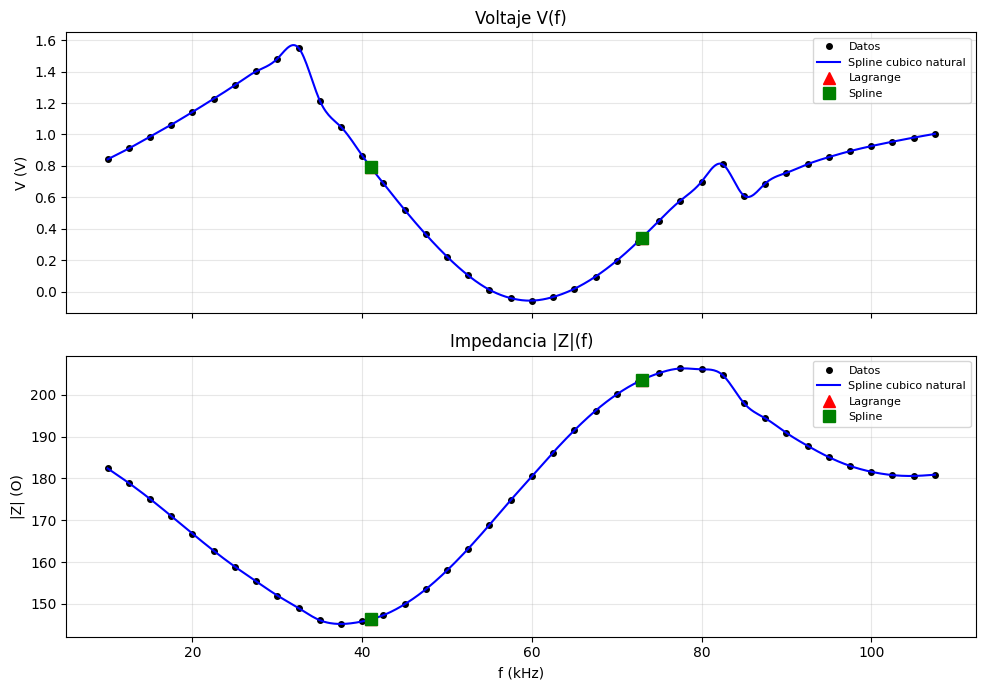

In [2]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Datos
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5,
    35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5,
    60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5,
    85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V = np.array([
    0.842,  0.911,  0.986,  1.062,  1.143,  1.227,  1.314,  1.401,  1.482,  1.551,
    1.216,  1.048,  0.866,  0.689,  0.521,  0.364,  0.223,  0.103,  0.012, -0.041,
   -0.057, -0.034,  0.018,  0.096,  0.197,  0.318,  0.452,  0.579,  0.700,  0.809,
    0.611,  0.688,  0.756,  0.811,  0.856,  0.894,  0.926,  0.954,  0.980,  1.004
])
Z = np.array([
    182.4, 178.9, 175.1, 171.0, 166.8, 162.7, 158.9, 155.4, 152.0, 149.0,
    146.1, 145.2, 145.8, 147.3, 149.9, 153.5, 158.0, 163.2, 168.9, 174.8,
    180.5, 186.2, 191.5, 196.2, 200.1, 203.1, 205.2, 206.3, 206.1, 204.7,
    198.0, 194.4, 190.9, 187.8, 185.1, 183.0, 181.6, 180.8, 180.6, 180.9
])

# Lagrange grado 2 con los 3 puntos mas cercanos
def lagrange2(xp, x_arr, y_arr):
    idx = np.sort(np.argsort(np.abs(x_arr - xp))[:3])
    x, y = x_arr[idx], y_arr[idx]
    result = 0.0
    for i in range(3):
        L = np.prod([(xp - x[j]) / (x[i] - x[j]) for j in range(3) if j != i])
        result += y[i] * L
    return result

# Spline cubico natural
cs_V = CubicSpline(f, V, bc_type='natural')
cs_Z = CubicSpline(f, Z, bc_type='natural')

# Resultados
targets = [41.0, 73.0]
print(f"{'f(kHz)':<8} {'V_Lagrange':>12} {'V_Spline':>10} {'Z_Lagrange':>12} {'Z_Spline':>10}")
print("-" * 56)
for t in targets:
    print(f"{t:<8.1f} {lagrange2(t,f,V):>12.4f} {float(cs_V(t)):>10.4f} "
          f"{lagrange2(t,f,Z):>12.4f} {float(cs_Z(t)):>10.4f}")

# Graficos
f_fine = np.linspace(f[0], f[-1], 600)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for ax, y_data, cs, ylabel, title in [
    (ax1, V, cs_V, 'V (V)',   'Voltaje V(f)'),
    (ax2, Z, cs_Z, '|Z| (O)', 'Impedancia |Z|(f)')
]:
    ax.plot(f, y_data, 'ko', ms=4, label='Datos')
    ax.plot(f_fine, cs(f_fine), 'b-', lw=1.5, label='Spline cubico natural')
    for t in targets:
        ax.plot(t, lagrange2(t, f, y_data), 'r^', ms=9, label=f'Lagrange {t} kHz')
        ax.plot(t, float(cs(t)),            'gs', ms=9, label=f'Spline {t} kHz')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    # Leyenda sin duplicados
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        key = l.split(' 4')[0].split(' 7')[0]
        if key not in seen:
            seen[key] = h
    ax.legend(seen.values(), seen.keys(), fontsize=8)

ax2.set_xlabel('f (kHz)')
plt.tight_layout()
plt.savefig('parte1_interpolacion.png', dpi=150, bbox_inches='tight')
plt.show()

f(kHz)     O(h^2)   O(h^4)   Spline  [V/kHz]
------------------------------------------
40.0      -0.0718  -0.0726  -0.0769
70.0       0.0444   0.0447   0.0447
100.0      0.0120   0.0119   0.0118

f=10.0        dp2            Spline
------------------------------------------
10.0       0.0264      ---   0.0270


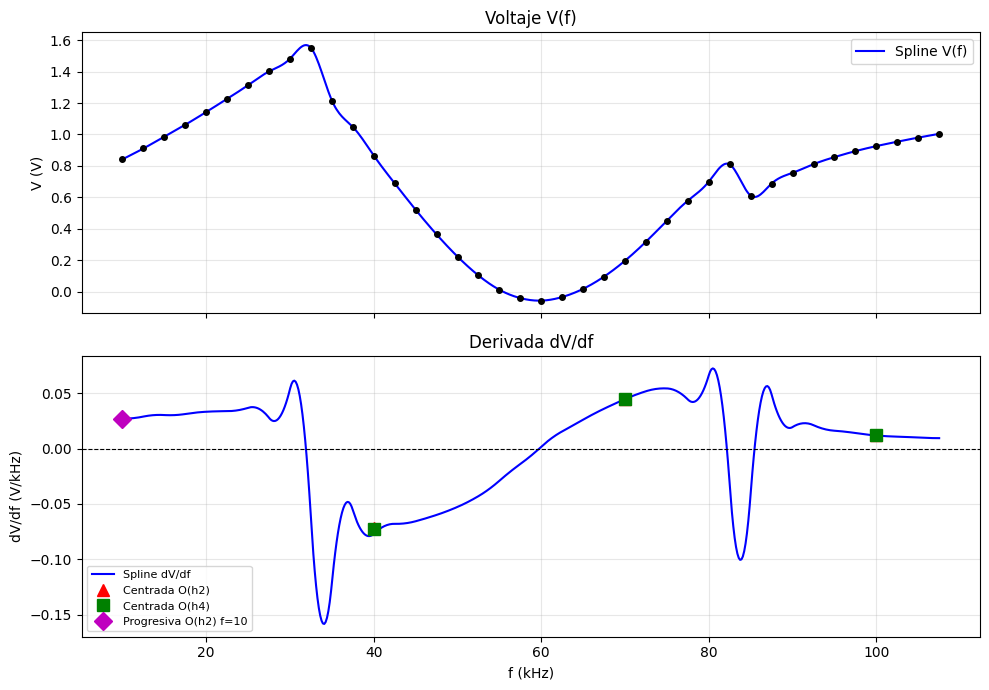

In [4]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Datos
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5,
    35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5,
    60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5,
    85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V = np.array([
    0.842,  0.911,  0.986,  1.062,  1.143,  1.227,  1.314,  1.401,  1.482,  1.551,
    1.216,  1.048,  0.866,  0.689,  0.521,  0.364,  0.223,  0.103,  0.012, -0.041,
   -0.057, -0.034,  0.018,  0.096,  0.197,  0.318,  0.452,  0.579,  0.700,  0.809,
    0.611,  0.688,  0.756,  0.811,  0.856,  0.894,  0.926,  0.954,  0.980,  1.004
])

h = 2.5

def V_at(freq):
    return V[np.where(f == freq)[0][0]]

# Formulas de diferencias finitas
def dc2(fp): return (V_at(fp+h) - V_at(fp-h)) / (2*h)
def dc4(fp): return (-V_at(fp+2*h) + 8*V_at(fp+h) - 8*V_at(fp-h) + V_at(fp-2*h)) / (12*h)
def dp2(fp): return (-3*V_at(fp) + 4*V_at(fp+h) - V_at(fp+2*h)) / (2*h)

# Spline y su derivada
cs_V = CubicSpline(f, V, bc_type='natural')
dcs  = cs_V.derivative()

# Resultados
print(f"{'f(kHz)':<8} {'O(h^2)':>8} {'O(h^4)':>8} {'Spline':>8}  [V/kHz]")
print("-" * 42)
for fp in [40.0, 70.0, 100.0]:
    print(f"{fp:<8.1f} {dc2(fp):>8.4f} {dc4(fp):>8.4f} {dcs(fp):>8.4f}")
print(f"\n{'f=10.0':<8} {'dp2':>8} {'':>8} {'Spline':>8}")
print("-" * 42)
print(f"{'10.0':<8} {dp2(10.0):>8.4f} {'---':>8} {float(dcs(10.0)):>8.4f}")

# Grafico
f_fine = np.linspace(f[0], f[-1], 600)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(f_fine, cs_V(f_fine), 'b-', lw=1.5, label='Spline V(f)')
ax1.plot(f, V, 'ko', ms=4)
ax1.set_ylabel('V (V)')
ax1.grid(True, alpha=0.3)
ax1.set_title('Voltaje V(f)')
ax1.legend()

ax2.plot(f_fine, dcs(f_fine), 'b-', lw=1.5, label="dV/df spline")
puntos_eval = [40.0, 70.0, 100.0]
for fp in puntos_eval:
    ax2.plot(fp, dc2(fp), 'r^', ms=9)
    ax2.plot(fp, dc4(fp), 'gs', ms=9)
ax2.plot(10.0, dp2(10.0), 'mD', ms=9)
ax2.axhline(0, color='k', lw=0.8, ls='--')
# Leyenda manual
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color='b', lw=1.5, label='Spline dV/df'),
       Line2D([0],[0], marker='^', color='r', ls='None', ms=9, label='Centrada O(h2)'),
       Line2D([0],[0], marker='s', color='g', ls='None', ms=9, label='Centrada O(h4)'),
       Line2D([0],[0], marker='D', color='m', ls='None', ms=9, label='Progresiva O(h2) f=10')]
ax2.legend(handles=leg, fontsize=8)
ax2.set_ylabel('dV/df (V/kHz)')
ax2.set_xlabel('f (kHz)')
ax2.grid(True, alpha=0.3)
ax2.set_title('Derivada dV/df')

plt.tight_layout()
plt.savefig('parte2_derivacion.png', dpi=150, bbox_inches='tight')
plt.show()

Raiz 1 biseccion: 55.4351 kHz  |  spline exacto: 55.4351 kHz
Raiz 2 biseccion: 64.2665 kHz  |  spline exacto: 64.2665 kHz


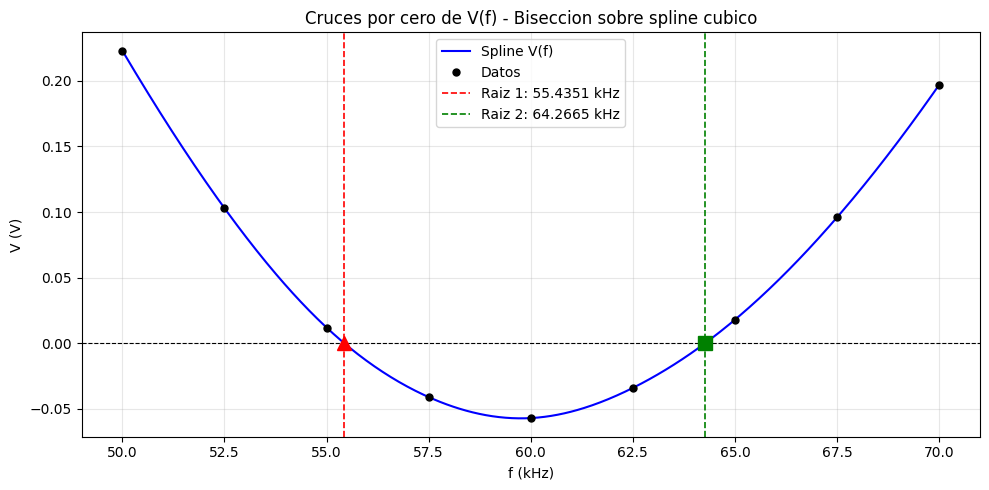

In [3]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# Datos
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5,
    35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5,
    60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5,
    85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V = np.array([
    0.842,  0.911,  0.986,  1.062,  1.143,  1.227,  1.314,  1.401,  1.482,  1.551,
    1.216,  1.048,  0.866,  0.689,  0.521,  0.364,  0.223,  0.103,  0.012, -0.041,
   -0.057, -0.034,  0.018,  0.096,  0.197,  0.318,  0.452,  0.579,  0.700,  0.809,
    0.611,  0.688,  0.756,  0.811,  0.856,  0.894,  0.926,  0.954,  0.980,  1.004
])

cs_V = CubicSpline(f, V, bc_type='natural')

def biseccion(func, a, b, tol=1e-6, max_iter=50):
    tabla = []
    for k in range(1, max_iter+1):
        c = (a + b) / 2
        fc = func(c)
        tabla.append((k, a, b, c, fc, b-a))
        if abs(fc) < tol or (b-a)/2 < tol:
            break
        if func(a)*fc < 0:
            b = c
        else:
            a = c
    return c, tabla

# Biseccion en ambos intervalos
r1, t1 = biseccion(cs_V, 55.0, 57.5)
r2, t2 = biseccion(cs_V, 62.5, 65.0)

# Raiz exacta del spline (referencia)
rs1 = brentq(cs_V, 55.0, 57.5)
rs2 = brentq(cs_V, 62.5, 65.0)

print(f"Raiz 1 biseccion: {r1:.4f} kHz  |  spline exacto: {rs1:.4f} kHz")
print(f"Raiz 2 biseccion: {r2:.4f} kHz  |  spline exacto: {rs2:.4f} kHz")

# Grafico
f_fine = np.linspace(50.0, 70.0, 500)
plt.figure(figsize=(10, 5))
plt.plot(f_fine, cs_V(f_fine), 'b-', lw=1.5, label='Spline V(f)')
plt.plot(f[(f >= 50) & (f <= 70)], V[(f >= 50) & (f <= 70)], 'ko', ms=5, label='Datos')
plt.axhline(0, color='k', lw=0.8, ls='--')
plt.axvline(r1, color='r', lw=1.2, ls='--', label=f'Raiz 1: {r1:.4f} kHz')
plt.axvline(r2, color='g', lw=1.2, ls='--', label=f'Raiz 2: {r2:.4f} kHz')
plt.plot(r1, 0, 'r^', ms=10)
plt.plot(r2, 0, 'gs', ms=10)
plt.xlabel('f (kHz)')
plt.ylabel('V (V)')
plt.title('Cruces por cero de V(f) - Biseccion sobre spline cubico')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('parte3_biseccion.png', dpi=150, bbox_inches='tight')
plt.show()

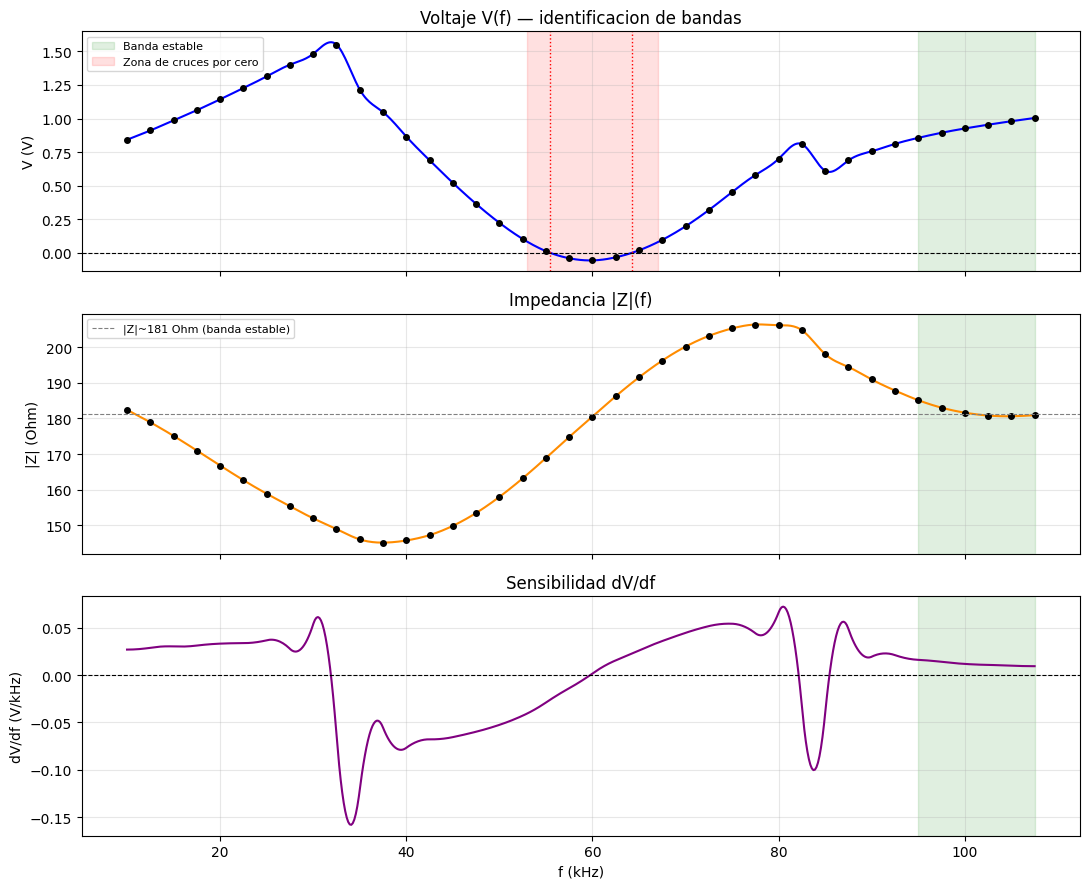

Banda 95-107.5 kHz:
  |dV/df| max en banda = 0.0161 V/kHz
  |Z| rango = [180.6, 185.1] Ohm
  V rango   = [0.856, 1.004] V

Minimo |Z| global: 145.2 Ohm en f=37.5 kHz
Maximo |Z| global: 206.3 Ohm en f=77.5 kHz
Maximo V global:   1.551 V  en f=32.5 kHz


In [5]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5,
    35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5,
    60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5,
    85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V = np.array([
    0.842,  0.911,  0.986,  1.062,  1.143,  1.227,  1.314,  1.401,  1.482,  1.551,
    1.216,  1.048,  0.866,  0.689,  0.521,  0.364,  0.223,  0.103,  0.012, -0.041,
   -0.057, -0.034,  0.018,  0.096,  0.197,  0.318,  0.452,  0.579,  0.700,  0.809,
    0.611,  0.688,  0.756,  0.811,  0.856,  0.894,  0.926,  0.954,  0.980,  1.004
])
Z = np.array([
    182.4, 178.9, 175.1, 171.0, 166.8, 162.7, 158.9, 155.4, 152.0, 149.0,
    146.1, 145.2, 145.8, 147.3, 149.9, 153.5, 158.0, 163.2, 168.9, 174.8,
    180.5, 186.2, 191.5, 196.2, 200.1, 203.1, 205.2, 206.3, 206.1, 204.7,
    198.0, 194.4, 190.9, 187.8, 185.1, 183.0, 181.6, 180.8, 180.6, 180.9
])

cs_V = CubicSpline(f, V, bc_type='natural')
cs_Z = CubicSpline(f, Z, bc_type='natural')
dcs  = cs_V.derivative()

f_fine = np.linspace(f[0], f[-1], 600)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# --- V(f) ---
ax1.plot(f_fine, cs_V(f_fine), 'b-', lw=1.5)
ax1.plot(f, V, 'ko', ms=4)
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.axvspan(95, 107.5, alpha=0.12, color='green', label='Banda estable')
ax1.axvspan(53, 67,    alpha=0.12, color='red',   label='Zona de cruces por cero')
ax1.axvline(55.4351, color='r', lw=1, ls=':')
ax1.axvline(64.2665, color='r', lw=1, ls=':')
ax1.set_ylabel('V (V)')
ax1.set_title('Voltaje V(f) — identificacion de bandas')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- |Z|(f) ---
ax2.plot(f_fine, cs_Z(f_fine), 'darkorange', lw=1.5)
ax2.plot(f, Z, 'ko', ms=4)
ax2.axvspan(95, 107.5, alpha=0.12, color='green')
ax2.axhline(cs_Z(101), color='gray', lw=0.8, ls='--', label='|Z|~181 Ohm (banda estable)')
ax2.set_ylabel('|Z| (Ohm)')
ax2.set_title('Impedancia |Z|(f)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- dV/df ---
ax3.plot(f_fine, dcs(f_fine), 'purple', lw=1.5)
ax3.axhline(0, color='k', lw=0.8, ls='--')
ax3.axvspan(95, 107.5, alpha=0.12, color='green')
ax3.set_ylabel('dV/df (V/kHz)')
ax3.set_xlabel('f (kHz)')
ax3.set_title('Sensibilidad dV/df')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parte4_discusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadisticas para la discusion
print("Banda 95-107.5 kHz:")
mask = (f >= 95)
print(f"  |dV/df| max en banda = {max(abs(dcs(f[mask]))):.4f} V/kHz")
print(f"  |Z| rango = [{min(Z[mask]):.1f}, {max(Z[mask]):.1f}] Ohm")
print(f"  V rango   = [{min(V[mask]):.3f}, {max(V[mask]):.3f}] V")
print(f"\nMinimo |Z| global: {min(Z):.1f} Ohm en f={f[np.argmin(Z)]:.1f} kHz")
print(f"Maximo |Z| global: {max(Z):.1f} Ohm en f={f[np.argmax(Z)]:.1f} kHz")
print(f"Maximo V global:   {max(V):.3f} V  en f={f[np.argmax(V)]:.1f} kHz")